In [1]:
import data_loader
import dispatch
import plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#CONSTANTS
CCGT_POWER=400 #MW
HEAT_RATE=1.95 #MW of gas to produce 1 MW of electricy
START_UP_COST=15000 #EUR
MIN_UP_TIME=4 #HOURS
MIN_DOWN_TIME=4 #HOURS
EMISSION_FACTOR=0.37 # tons of CO2 per MWh of electricity produced
CO2_PRICE=70 #EUR/ton potentially to be replaced with price series


# CCGT valuation — data loading and analysis

Valuation of a combined-cycle gas turbine (CCGT) plant modelled as a
strip of spark-spread options, using 2023 Italian day-ahead electricity
prices (PUN) and Dutch TTF gas prices.

This notebook loads and inspects the price data; the valuation and
dispatch-optimization logic lives in the project modules.

## 1. Load price data

Hourly PUN and daily TTF prices are loaded and aligned by
`data_loader.load_pun_ttf_prices`, which merges the daily gas price onto
the hourly grid (forward-filled over weekends and holidays) and returns
a DataFrame indexed by hour of the year. Running with `diagnostic=True`
checks the load for missing values and the expected per-day hour counts.

In [2]:
pun_ttf_prices=data_loader.load_pun_ttf_prices(diagnostic=True)

display(pun_ttf_prices.head())
display(pun_ttf_prices.tail())

diagnostic OK: 8760 hours, 365 days (363 x 24h, one 23h, one 25h), no missing values


,time,pun_price,ttf_price
0,2023-01-01 00:00:00,195.90,76.315
1,2023-01-01 01:00:00,191.09,76.315
2,2023-01-01 02:00:00,187.95,76.315
3,2023-01-01 03:00:00,187.82,76.315
4,2023-01-01 04:00:00,187.74,76.315


,time,pun_price,ttf_price
8755,2023-12-31 19:00:00,136.07000,32.35
8756,2023-12-31 20:00:00,130.00000,32.35
8757,2023-12-31 21:00:00,117.23116,32.35
8758,2023-12-31 22:00:00,108.96000,32.35
8759,2023-12-31 23:00:00,106.12000,32.35


## 2. Computing and visualizing spark spread

In [3]:
pun_ttf_prices["spark_spread"]=dispatch.compute_spark_spread(
    pun_price=pun_ttf_prices["pun_price"], 
    ttf_price=pun_ttf_prices["ttf_price"], 
    heat_rate=HEAT_RATE, 
    emission_factor=EMISSION_FACTOR, 
    co2_price=CO2_PRICE,
)

pun_ttf_prices.head()

,time,pun_price,ttf_price,spark_spread
0,2023-01-01 00:00:00,195.90,76.315,21.18575
1,2023-01-01 01:00:00,191.09,76.315,16.37575
2,2023-01-01 02:00:00,187.95,76.315,13.23575
3,2023-01-01 03:00:00,187.82,76.315,13.10575
4,2023-01-01 04:00:00,187.74,76.315,13.02575


(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Spark spread orario — settimana campione'}, ylabel='€/MWh'>)

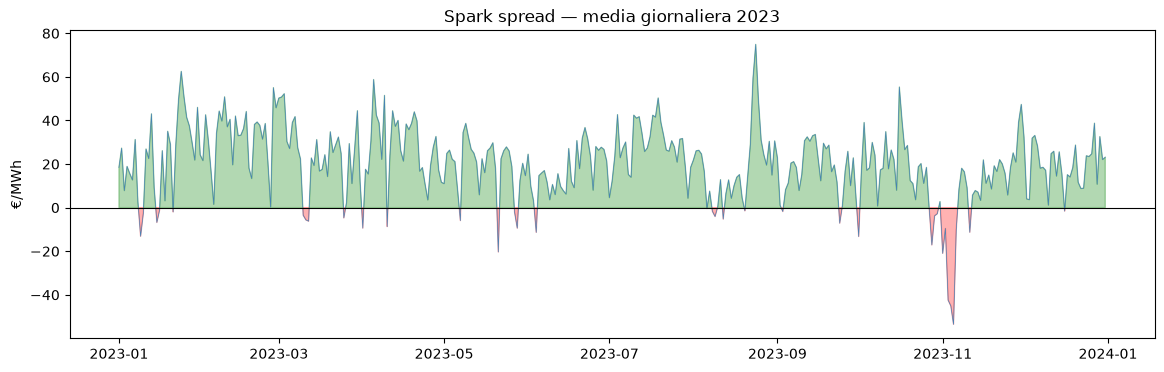

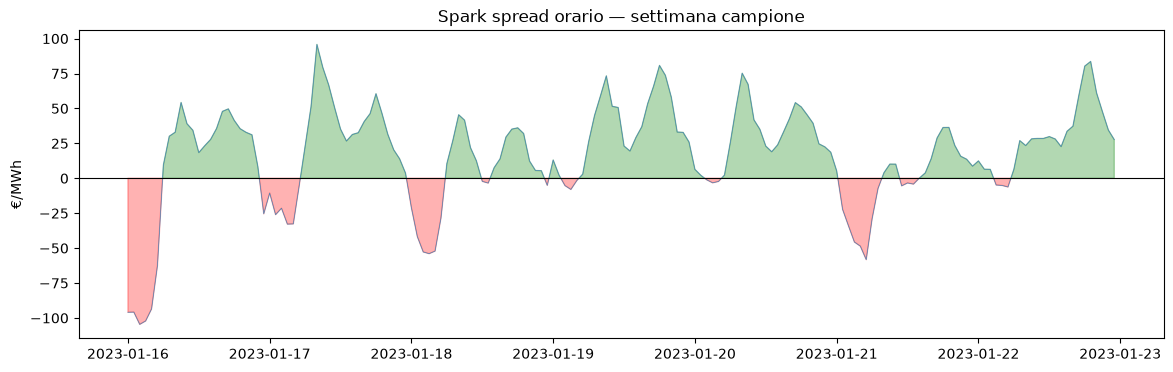

In [4]:
# media giornaliera
daily = (
    pun_ttf_prices.set_index("time")["spark_spread"]
    .resample("D")
    .mean()
)

plotting.plot_series_vs_threshold(
    daily.index, daily.values,
    title="Spark spread — media giornaliera 2023", ylabel="€/MWh",
)

# settimana campione
week = pun_ttf_prices[(pun_ttf_prices["time"] >= "2023-01-16") &
              (pun_ttf_prices["time"] < "2023-01-23")]
plotting.plot_series_vs_threshold(
    week["time"], week["spark_spread"],
    title="Spark spread orario — settimana campione", ylabel="€/MWh",
)

# 3.Optimization Strategies

### Naive Strategy: turbine always ON

In [9]:
total_revs_naive=pun_ttf_prices["spark_spread"].sum()*CCGT_POWER
formatted_revs_naive = f"{total_revs_naive:,.0f}".replace(",", " ")

print(
    f"""By keeping the turbine always ON,
in one year the total gross revenues is {formatted_revs_naive} EUR
"""
)

By keeping the turbine always ON,
in one year the total gross revenues is 71 917 741 EUR



### Ideal Strategy with no constraints: switching is free and always possible

In [13]:
total_revs_ideal=(
    pun_ttf_prices[pun_ttf_prices["spark_spread"]>0]["spark_spread"]
    .sum()*CCGT_POWER
)

formatted_revs_ideal = f"{total_revs_ideal:,.0f}".replace(",", " ")
diff_ideal_naive=total_revs_ideal-total_revs_naive

formatted_diff_ideal_naive = f"{diff_ideal_naive:,.0f}".replace(",", " ")

print(
    f"""If swithcing were free and always possible, in one year 
    the total gross revenues would be {formatted_revs_ideal} EUR,
    which is {formatted_diff_ideal_naive} more than the
    revenues generated by keeping the turbine always ON.
"""
)

If swithcing were free and always possible, in one year 
    the total gross revenues would be 83 898 736 EUR,
    which is 11 980 994 more than the
    revenues generated by keeping the turbine always ON.

